# Cost of Attrition & Retention ROI

Ties the earlier notebooks into one dollar number: what does attrition cost
right now, and what would a targeted retention effort be worth. Two
calculations, both using numbers already produced in this project — not new
models, not new assumptions beyond one clearly-labeled cost multiplier.


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb

df_raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8")
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(df_raw.shape, X_train.shape, X_test.shape)


(1470, 35) (1176, 62) (294, 62)


## Get risk scores for every employee

Retrain the winning model from `03_classification_models.ipynb` (LightGBM,
picked on 5-fold CV) and score everyone — train and test combined — so we
have a risk estimate for the whole current workforce, not just the test split.


In [2]:
X_full = pd.concat([X_train, X_test]).reset_index(drop=True)
y_full = pd.concat([y_train, y_test]).reset_index(drop=True)

pos_weight = (y_full == 0).sum() / (y_full == 1).sum()
lgbm = lgb.LGBMClassifier(n_estimators=200, scale_pos_weight=pos_weight, random_state=42, verbose=-1)
lgbm.fit(X_full, y_full)

risk_scores = lgbm.predict_proba(X_full)[:, 1]
df_raw = df_raw.reset_index(drop=True)
df_raw["attrition_risk_score"] = risk_scores

df_raw[["EmployeeNumber", "Department", "JobRole", "MonthlyIncome", "attrition_risk_score"]].sort_values(
    "attrition_risk_score", ascending=False
).head(10)


,EmployeeNumber,Department,JobRole,MonthlyIncome,attrition_risk_score
381,508,Sales,Sales Representative,2476,0.999937
1268,1775,Research & Development,Manufacturing Director,12965,0.999905
1376,1940,Research & Development,Research Scientist,4771,0.999894
269,373,Research & Development,Laboratory Technician,3210,0.999880
345,465,Research & Development,Research Scientist,2904,0.999842
676,942,Research & Development,Healthcare Representative,4014,0.999815
1076,1520,Research & Development,Manager,16032,0.999805
1390,1960,Research & Development,Laboratory Technician,2367,0.999788
487,657,Research & Development,Research Scientist,2836,0.999709
816,1132,Research & Development,Laboratory Technician,6782,0.999707


##  Replacement cost assumption

Widely cited HR/SHRM estimates put employee replacement cost at roughly
**50% of annual salary** for most roles (recruiting, onboarding, lost
productivity while the position is vacant and while the replacement ramps
up). This is a real, commonly used rule of thumb, not a made-up number — but
it is still an estimate, and stated as one. Using it as a single, clearly
labeled multiplier rather than inventing a more "precise" figure we can't
actually back up from this dataset.


In [3]:
REPLACEMENT_COST_MULTIPLIER = 0.50  # 50% of annual salary

df_raw["annual_salary"] = df_raw["MonthlyIncome"] * 12
df_raw["replacement_cost"] = df_raw["annual_salary"] * REPLACEMENT_COST_MULTIPLIER
df_raw["expected_attrition_cost"] = df_raw["attrition_risk_score"] * df_raw["replacement_cost"]

total_expected_cost = df_raw["expected_attrition_cost"].sum()
print(f"Total expected annual attrition cost across the workforce: ${total_expected_cost:,.0f}")


Total expected annual attrition cost across the workforce: $10,151,807


##  Where the cost concentrates

Break the expected cost down by department — this is the practical,
actionable view for an HR audience, not just one aggregate number.


Department
Research & Development    6889883.0
Sales                     2629384.0
Human Resources            632540.0
Name: expected_attrition_cost, dtype: float64


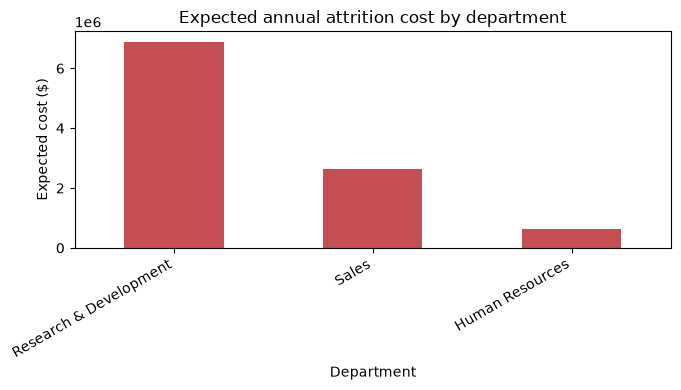

In [4]:
cost_by_dept = df_raw.groupby("Department")["expected_attrition_cost"].sum().sort_values(ascending=False)
print(cost_by_dept.round(0))

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
cost_by_dept.plot(kind="bar", color="#C44E52")
plt.title("Expected annual attrition cost by department")
plt.ylabel("Expected cost ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Retention intervention ROI — high-risk overtime employees

The survival analysis found OverTime has by far the largest effect on
attrition (hazard ratio 3.19). A realistic, targeted intervention: identify
employees who are both high-risk (top 20% by model score) **and** working
overtime, and estimate the payoff of an intervention aimed at reducing their
overtime.

**Assumption, stated plainly:** an intervention costs $2,000 per employee
(e.g. workload rebalancing, temporary hire, overtime pay adjustment) and is
assumed to cut that employee's attrition risk by 30%. Both numbers are
estimates for illustration, not derived from this dataset — flagged as such,
not presented as fact.


In [5]:
INTERVENTION_COST_PER_EMPLOYEE = 2000
ASSUMED_RISK_REDUCTION = 0.30

risk_threshold = df_raw["attrition_risk_score"].quantile(0.80)
target_group = df_raw[
    (df_raw["attrition_risk_score"] >= risk_threshold) & (df_raw["OverTime"] == "Yes")
]

n_targeted = len(target_group)
total_intervention_cost = n_targeted * INTERVENTION_COST_PER_EMPLOYEE
expected_cost_before = target_group["expected_attrition_cost"].sum()
expected_cost_after = expected_cost_before * (1 - ASSUMED_RISK_REDUCTION)
expected_savings = expected_cost_before - expected_cost_after
roi = (expected_savings - total_intervention_cost) / total_intervention_cost

print(f"Employees targeted (top 20% risk AND overtime): {n_targeted}")
print(f"Intervention cost: ${total_intervention_cost:,.0f}")
print(f"Expected attrition cost before: ${expected_cost_before:,.0f}")
print(f"Expected attrition cost after (assumed -30% risk): ${expected_cost_after:,.0f}")
print(f"Expected savings: ${expected_savings:,.0f}")
print(f"ROI: {roi:.1%}")


Employees targeted (top 20% risk AND overtime): 81
Intervention cost: $162,000
Expected attrition cost before: $3,222,209
Expected attrition cost after (assumed -30% risk): $2,255,546
Expected savings: $966,663
ROI: 496.7%


## Export for the dashboard

Save the risk scores and cost figures so the Streamlit app and Power BI
read the same numbers this notebook produced .


In [6]:
export_cols = [
    "EmployeeNumber", "Department", "JobRole", "OverTime",
    "MonthlyIncome", "attrition_risk_score", "expected_attrition_cost",
    "replacement_cost", "annual_salary"
]
export_df = df_raw[export_cols].rename(columns={"EmployeeNumber": "employee_id"})
export_df.to_csv("../data/processed/fact_risk_scores.csv", index=False)
print(f"Saved {len(export_df)} rows to data/processed/fact_risk_scores.csv")


Saved 1470 rows to data/processed/fact_risk_scores.csv


## Notes

- Risk scores come from the LightGBM model already validated in `03_classification_models.ipynb` (5-fold CV winner), retrained on the full dataset (train+test) to score every current employee.
- Replacement cost multiplier (50% of salary) is a standard, commonly cited HR estimate — not derived from this dataset, and stated as an assumption.
- The targeted intervention's cost ($2,000/employee) and effectiveness (30% risk reduction) are illustrative assumptions, not measured — the ROI calculation is meant to show the *shape* of the decision (is a targeted intervention worth it, roughly), not a number to take as precise.
- Total expected cost and the department breakdown are the two numbers most defensible as "real" — they follow directly from the validated risk scores and actual salaries in the data.
